**Data and Library setup**

In [1]:
!pip install matplotlib seaborn -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins',
    'logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate',
    'srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

In [3]:
data_train=pd.read_csv('/content/KDDTrain+.txt',names=columns)
data_test=pd.read_csv('/content/KDDTest+.txt',names=columns)

In [4]:
data=pd.concat([data_train,data_test])

In [5]:
data=data.reset_index(drop=True)

In [6]:
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     148517 non-null  int64  
 1   protocol_type                148517 non-null  object 
 2   service                      148517 non-null  object 
 3   flag                         148517 non-null  object 
 4   src_bytes                    148517 non-null  int64  
 5   dst_bytes                    148517 non-null  int64  
 6   land                         148517 non-null  int64  
 7   wrong_fragment               148517 non-null  int64  
 8   urgent                       148517 non-null  int64  
 9   hot                          148517 non-null  int64  
 10  num_failed_logins            148517 non-null  int64  
 11  logged_in                    148517 non-null  int64  
 12  num_compromised              148517 non-null  int64  
 13 

In [8]:
print(data['protocol_type'].unique())
print(data['service'].unique())
print(data['flag'].unique())
print(data['label'].unique())
print(data['label'].unique())

['tcp' 'udp' 'icmp']
['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']
['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']
['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl' 'saint' 'mscan' 'apache2' 'snmpgetattack'
 'processtable' 'h

**EDA- Exploratory Data Analysis**

In [9]:
label_map = {
    'normal': 'normal',
    'neptune':'DoS','back':'DoS','land':'DoS','pod':'DoS',
    'smurf':'DoS','teardrop':'DoS','mailbomb':'DoS',
    'apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe',
    'satan':'Probe','mscan':'Probe','saint':'Probe',
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L',
    'multihop':'R2L','phf':'R2L','spy':'R2L','warezclient':'R2L',
    'warezmaster':'R2L','sendmail':'R2L','named':'R2L',
    'snmpgetattack':'R2L','snmpguess':'R2L','xlock':'R2L',
    'xsnoop':'R2L','worm':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R',
    'rootkit':'U2R','httptunnel':'U2R','ps':'U2R',
    'sqlattack':'U2R','xterm':'U2R'
}

In [10]:

data['attack']=data['label'].map(label_map)
data.drop('label',axis=1,inplace=True)
data['attack'].value_counts()


,count
attack,
normal,77054
DoS,53385
Probe,14077
R2L,3749
U2R,252


In [11]:
data['attack'].isnull().sum()

np.int64(0)

In [12]:
data.dropna(subset='attack',inplace=True)

In [13]:
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty,attack
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,20,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,15,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,19,DoS
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,21,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21,normal


**Pre-Processing and Feature Enginnering**

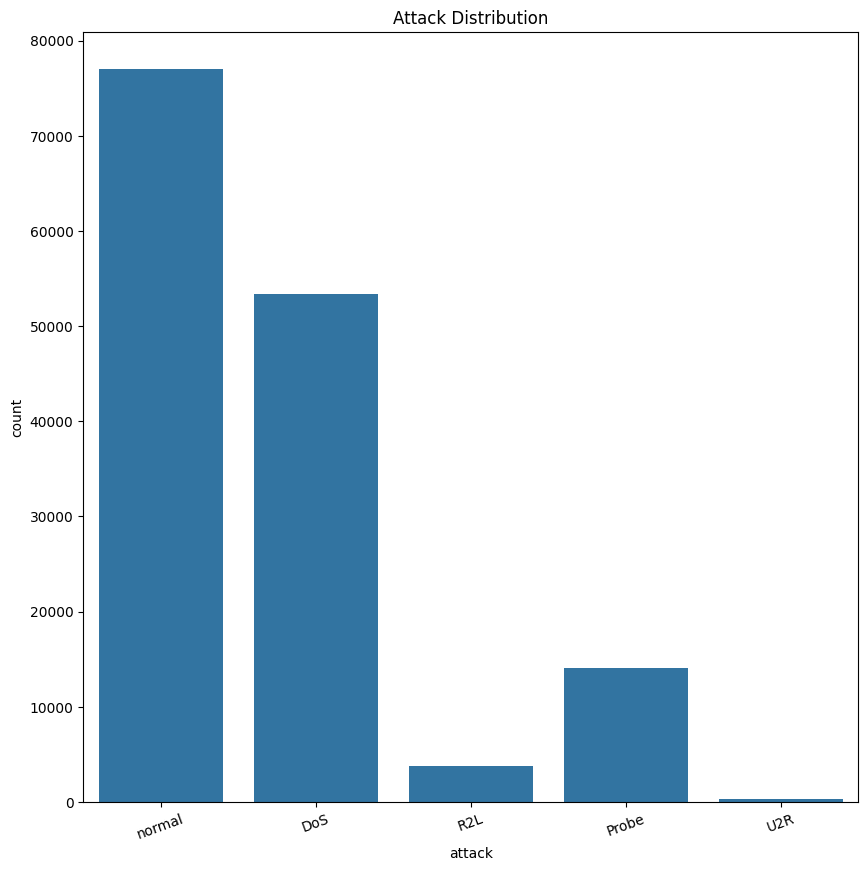

In [14]:
plt.figure(figsize=(10,10))
sns.countplot(x='attack',data=data)
plt.title('Attack Distribution')
plt.xticks(rotation=20)
plt.show()

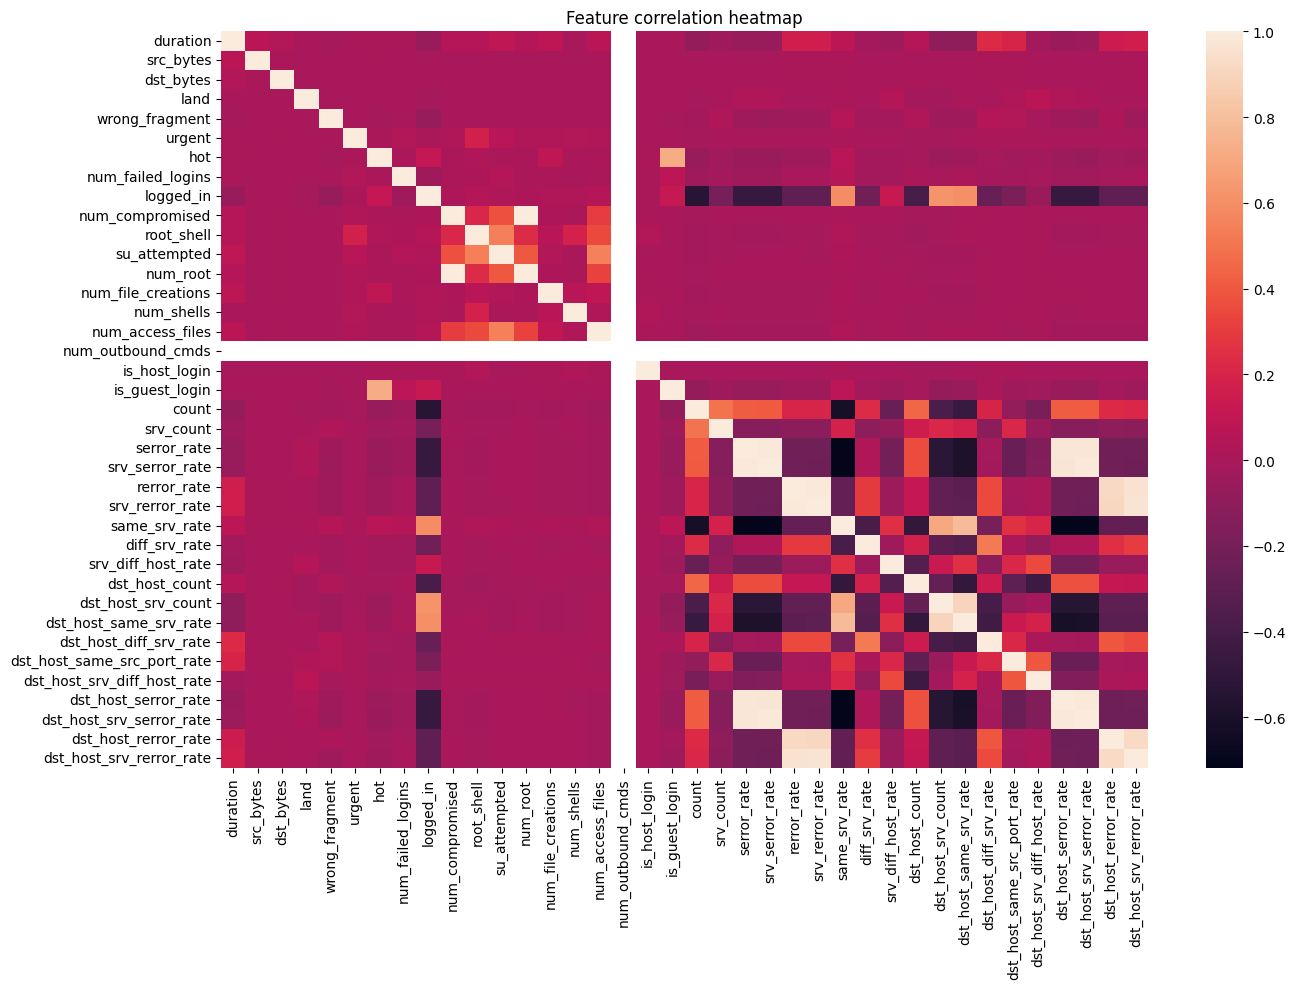

In [15]:
df_num = data.select_dtypes(include='number').drop('difficulty', axis=1)
plt.figure(figsize=(14,10))
sns.heatmap(df_num.corr())
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150)
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [17]:
cat_colms=['protocol_type','service','flag']
lb=LabelEncoder()
for col in cat_colms:
  data[col]=lb.fit_transform(data[col])

In [18]:
x=data.drop(['attack','difficulty'],axis=1)
y=data['attack']

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(118813, 41)
(118813,)
(29704, 41)
(29704,)


In [21]:
print(y_train.unique())

['normal' 'DoS' 'Probe' 'R2L' 'U2R']


In [22]:
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)

**Model Training and Evaluating**

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

lr=LogisticRegression(random_state=12345)
lr.fit(x_train_sc,y_train)
y_pred=lr.predict(x_test_sc)

print("=== Logistic Regression ===")
print(f'Accuracy Score {accuracy_score(y_test,y_pred)}')
print(f'Confusion Matrix {confusion_matrix(y_test,y_pred)}')
print(f'Classification Report {classification_report(y_test,y_pred)}')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
Accuracy Score 0.9431389711823324
Confusion Matrix [[10529    19     0     0   139]
 [   27  2361    37     9   315]
 [    6     4   265     4   482]
 [    0     1     6    20    30]
 [  192   325    87     6 14840]]
Classification Report               precision    recall  f1-score   support

         DoS       0.98      0.99      0.98     10687
       Probe       0.87      0.86      0.86      2749
         R2L       0.67      0.35      0.46       761
         U2R       0.51      0.35      0.42        57
      normal       0.94      0.96      0.95     15450

    accuracy                           0.94     29704
   macro avg       0.79      0.70      0.73     29704
weighted avg       0.94      0.94      0.94     29704



In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt=DecisionTreeClassifier(max_depth=8,class_weight='balanced',random_state=12345)
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

print("=== Decision Tree ===")
print(f'Accuracy Score {accuracy_score(y_test,y_pred)}')
print(f'Confusion Matrix {confusion_matrix(y_test,y_pred)}')
print(f'Classification Report {classification_report(y_test,y_pred)}')


=== Decision Tree ===
Accuracy Score 0.9283934823592782
Confusion Matrix [[10601    10     7     2    67]
 [    5  2651    58    17    18]
 [    2     1   732     8    18]
 [    0     0     4    45     8]
 [   32   141  1625   104 13548]]
Classification Report               precision    recall  f1-score   support

         DoS       1.00      0.99      0.99     10687
       Probe       0.95      0.96      0.95      2749
         R2L       0.30      0.96      0.46       761
         U2R       0.26      0.79      0.39        57
      normal       0.99      0.88      0.93     15450

    accuracy                           0.93     29704
   macro avg       0.70      0.92      0.75     29704
weighted avg       0.97      0.93      0.94     29704



In [25]:
print(dt.classes_)

['DoS' 'Probe' 'R2L' 'U2R' 'normal']


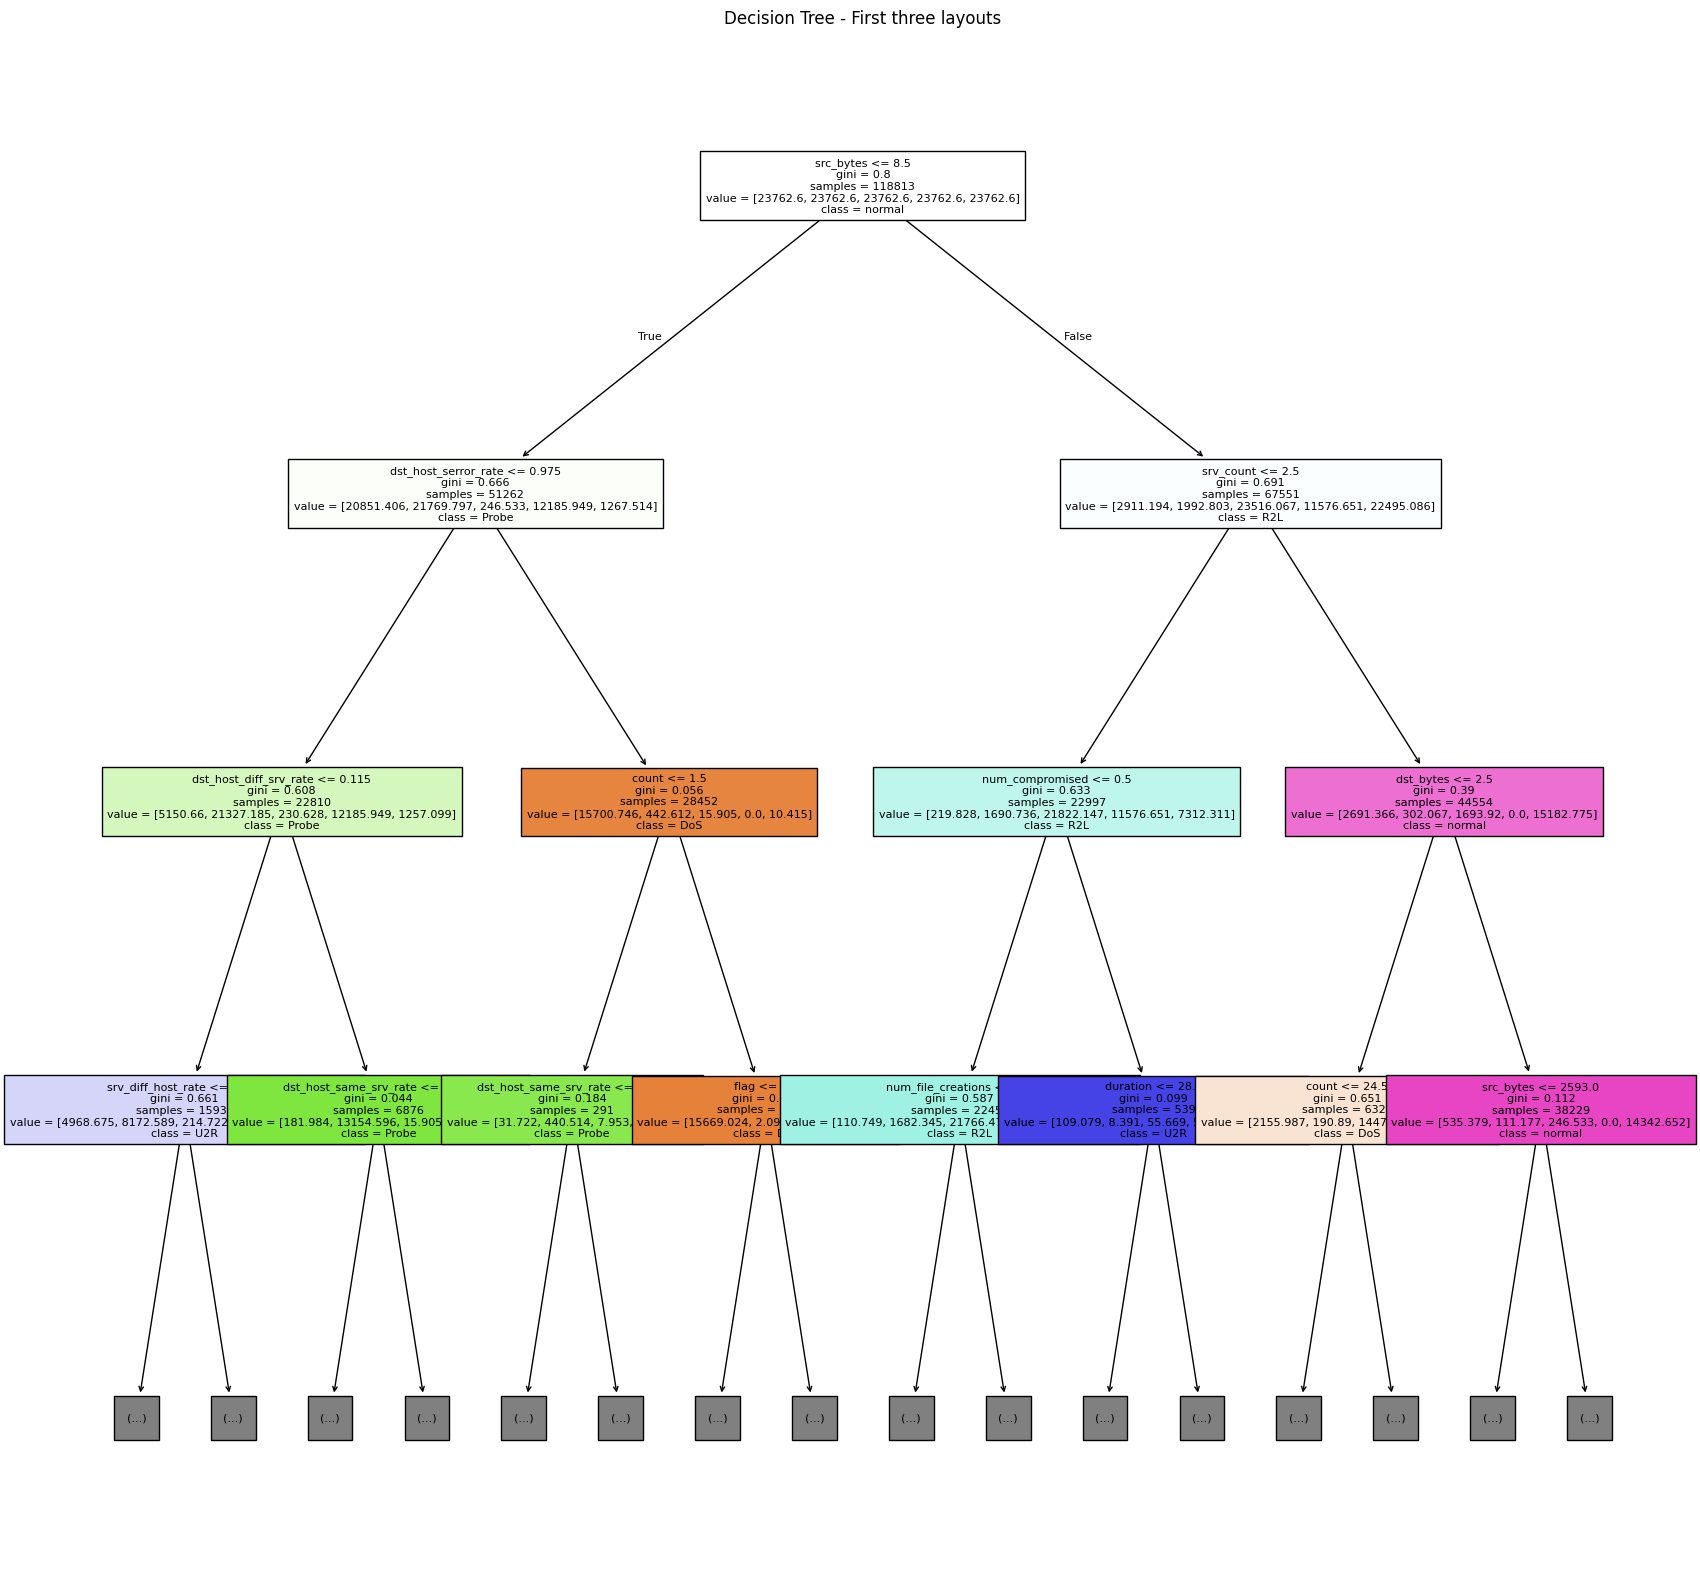

In [26]:
plt.figure(figsize=(20,20))
plot_tree(dt,max_depth=3,feature_names=x.columns,filled=True,class_names=[str(i) for i in dt.classes_],fontsize=8)
plt.title('Decision Tree - First three layouts')
plt.show()

In [27]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=12345,n_jobs=-1)
rfc.fit(x_train,y_train)
y_pred_rfc=rfc.predict(x_test)

print("=== Random Forest ===")
print(f'Accuracy Score {accuracy_score(y_test,y_pred_rfc)}')
print(f'Confusion Matrix {confusion_matrix(y_test,y_pred_rfc)}')
print(f'Classification Report {classification_report(y_test,y_pred_rfc)}')

=== Random Forest ===
Accuracy Score 0.9949501750605979
Confusion Matrix [[10676     4     0     0     7]
 [    0  2734     0     0    15]
 [    0     1   698     1    61]
 [    0     0     2    40    15]
 [    9    13    20     2 15406]]
Classification Report               precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     10687
       Probe       0.99      0.99      0.99      2749
         R2L       0.97      0.92      0.94       761
         U2R       0.93      0.70      0.80        57
      normal       0.99      1.00      1.00     15450

    accuracy                           0.99     29704
   macro avg       0.98      0.92      0.95     29704
weighted avg       0.99      0.99      0.99     29704



In [28]:
important=pd.Series(rfc.feature_importances_,index=x.columns)
top15=important.nlargest(15)


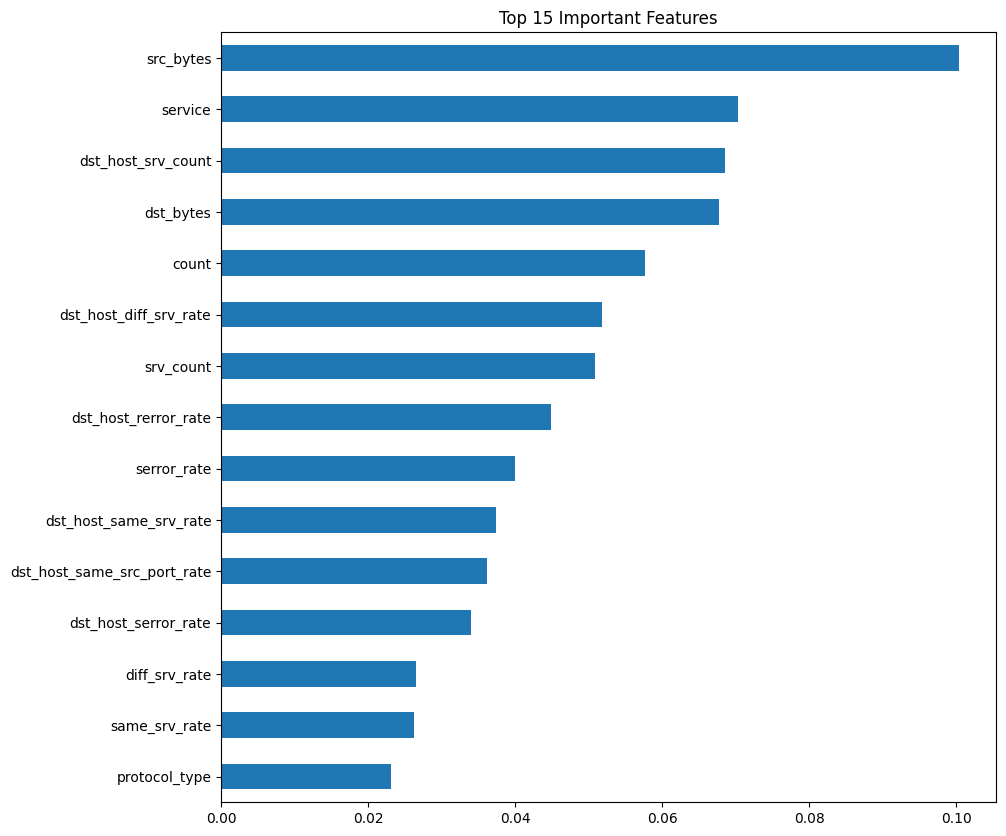

In [29]:
plt.figure(figsize=(10,10))
top15.sort_values().plot(kind='barh')
plt.title('Top 15 Important Features')
plt.show()

In [30]:
import joblib

In [31]:
joblib.dump(lr,'logistic_regression.pkl')
joblib.dump(dt,'decision_tree.pkl')
joblib.dump(rfc,'random_forest.joblib',compress=9)
joblib.dump(sc,'standard_scaler.pkl')
print('All models saved')

All models saved


In [34]:
import os
os.makedirs('models', exist_ok=True)
joblib.dump(list(x.columns), 'models/feature_columns.pkl')

['models/feature_columns.pkl']